## **Epileptic Sezuise prediction** 

- 3 – Recording of seizure events (including activities such as eye blinking or constant staring)
- 2 – Recording of focal seizures
- 1 – Recording of generalized seizures
- 0 – Recording of healthy subjects (control group without epileptic seizures)

In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA


#### 01. Loading the data

In [3]:
df = pd.read_csv('/home/yassine/DS_projects/epileptic_seizure_detection_classification/Data/BEED_Data.csv')

In [4]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


#### 02. Understand the data:

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
 16  y       8000 non-null   int64
dtypes: int64(17)
memory usage: 1.0 MB


In [6]:
df.shape

(8000, 17)

In [7]:
# Checking duplicates 
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='y', ylabel='count'>

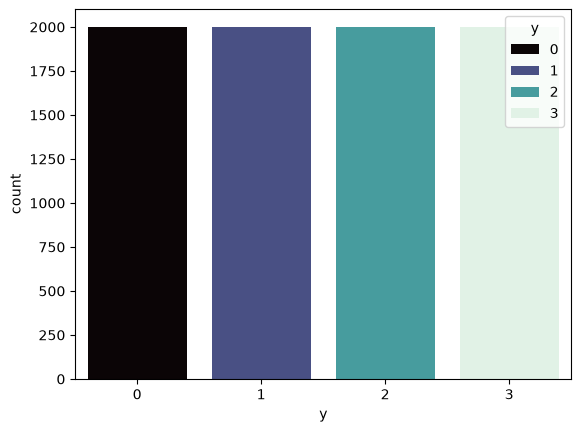

In [8]:
# checking the target variable 
sns.countplot(x=df['y'],palette='mako',hue=df['y'])

the target variable classes are perfectly balanced each class represents 25% of the data 

#### **Data distribution : Histogram**

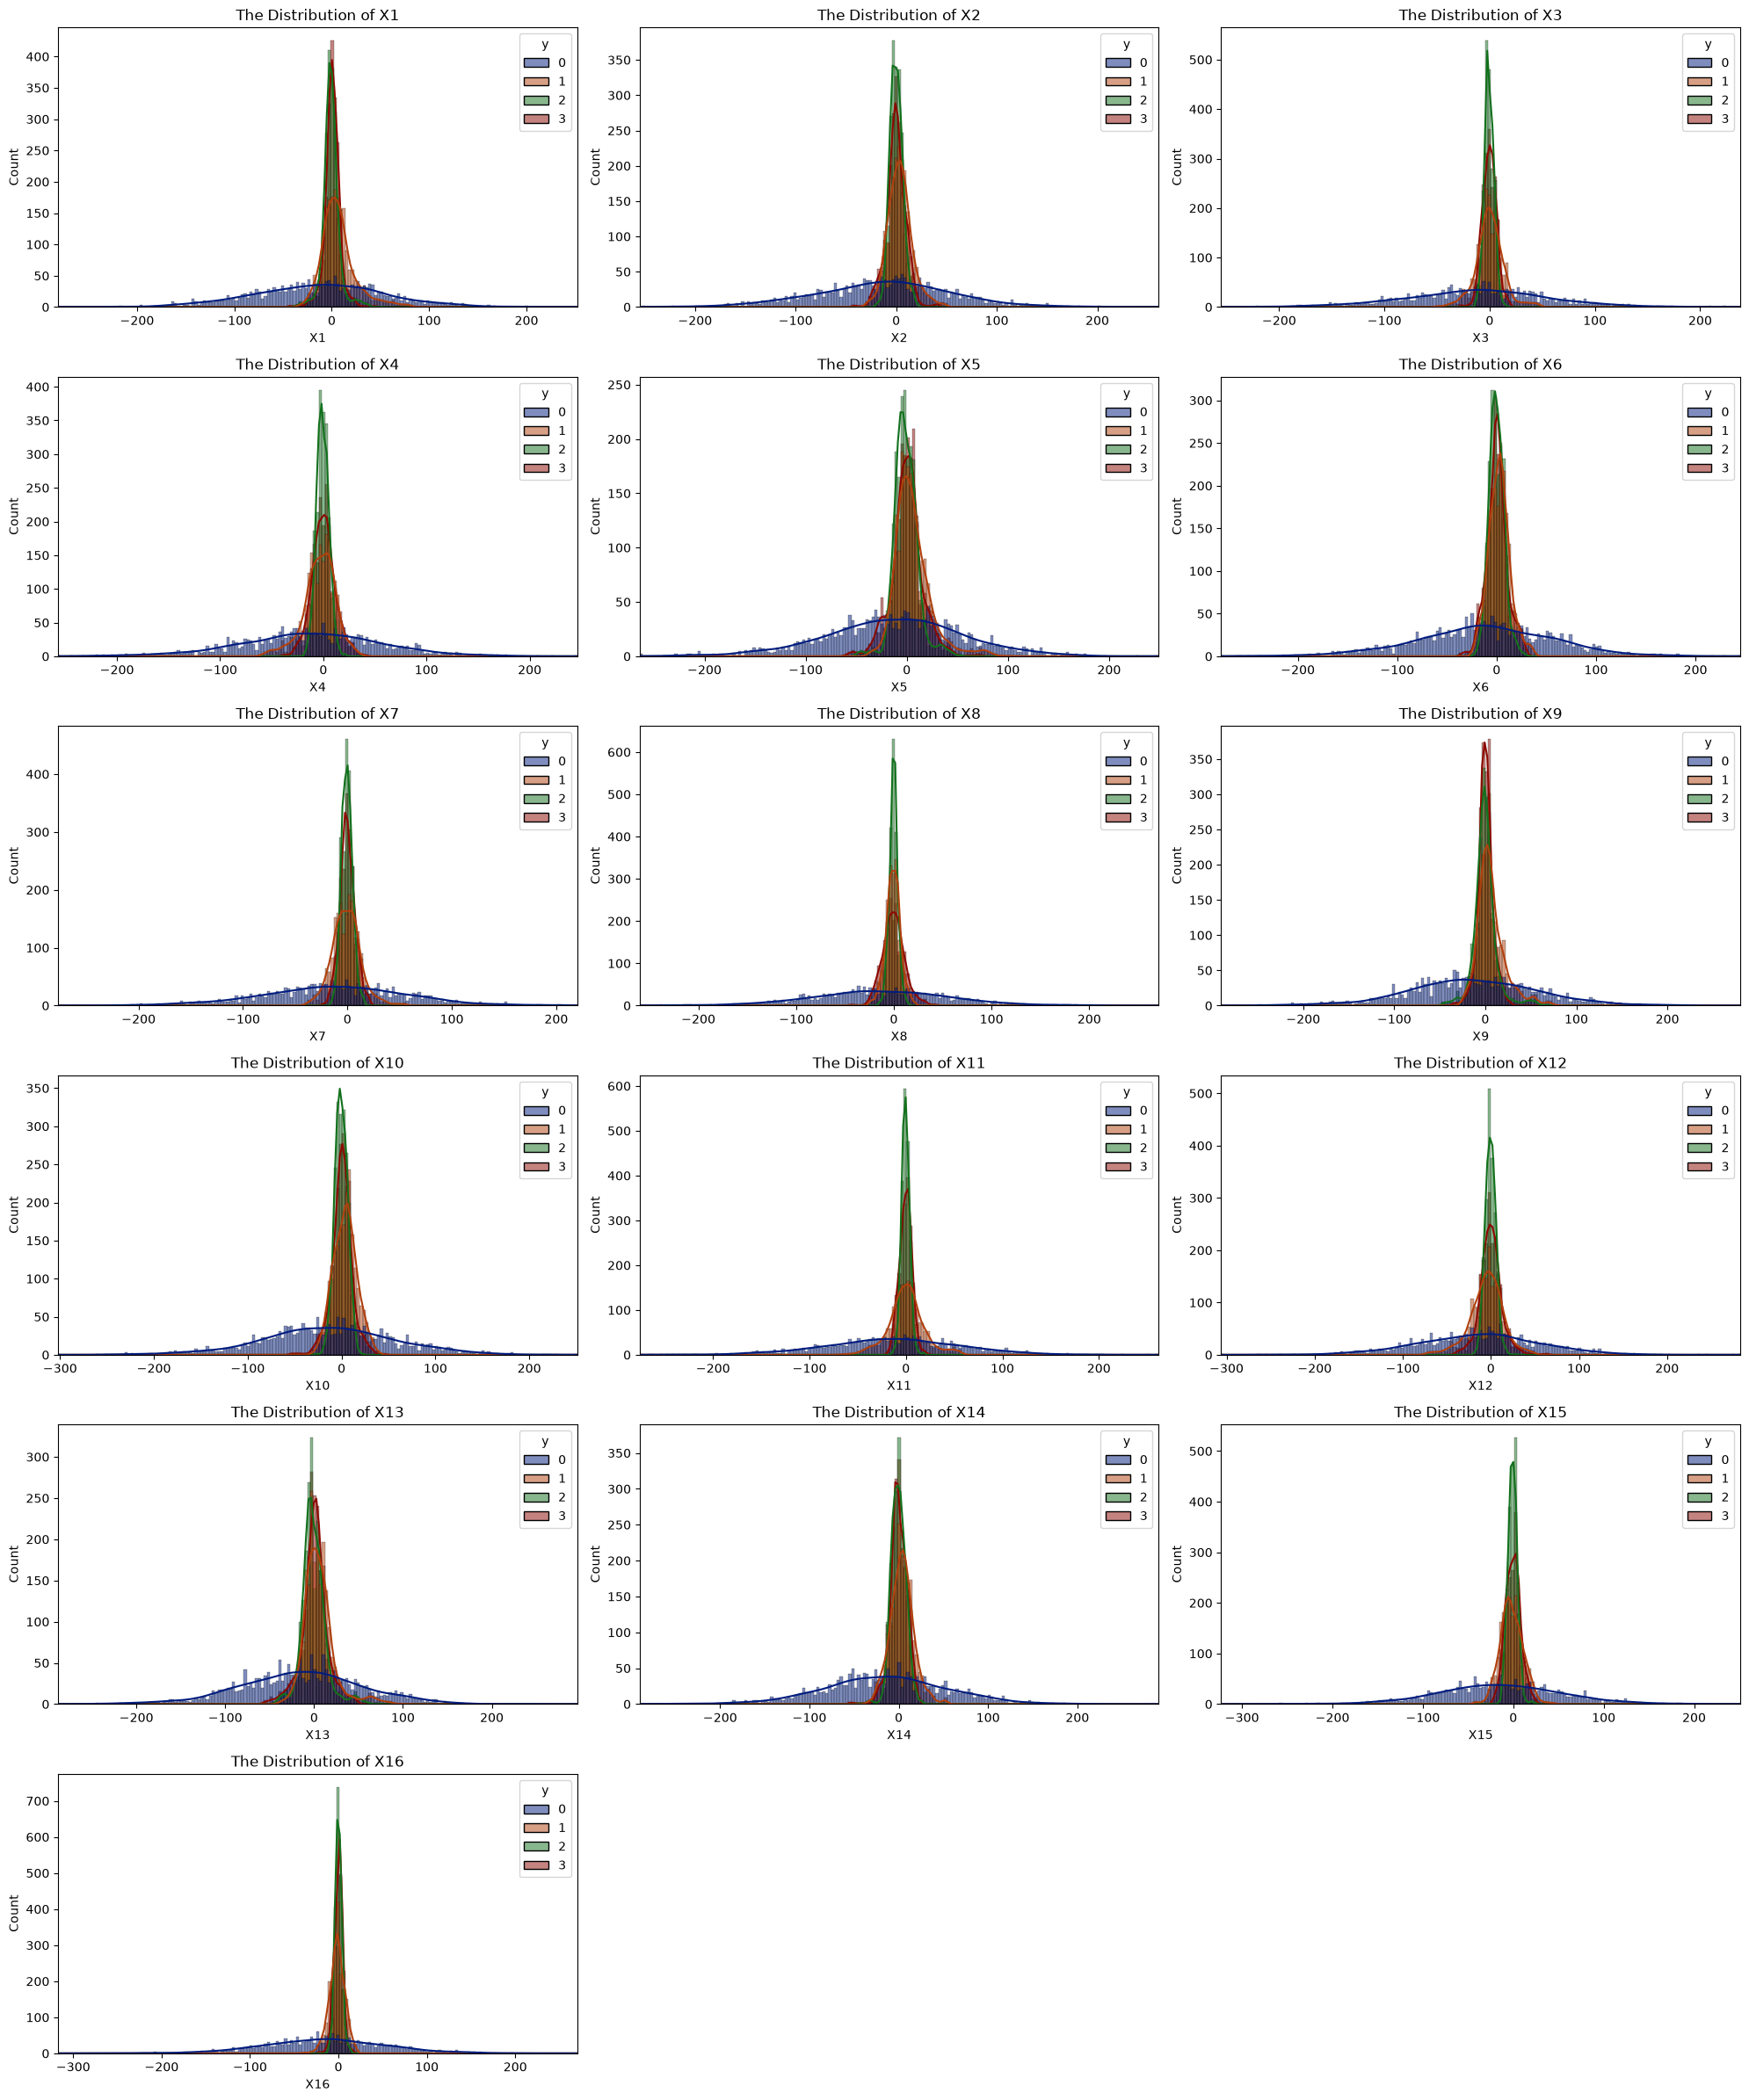

In [9]:
fig , ax = plt.subplots(6,3,figsize=(20,24))
ax = ax.flatten()

for i , col in enumerate(df.columns[:-1]):

        sns.histplot(x=df[col],
        hue=df['y'],
        palette="dark",
        ax=ax[i],
        kde=True)

        ax[i].set_xlim(df[col].min(),df[col].max())
        ax[i].set_title(f"The Distribution of {col}") 

for j in range(len(df.columns[:-1]), len(ax)):
        fig.delaxes(ax[j])


plt.tight_layout()



In [10]:
df.columns[:-1]

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16'],
      dtype='str')

In [11]:
df[df.columns[:-1]].describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16
count,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,-1.490375,-2.189375,-3.23750,-4.119375,-1.821625,-2.311750,-3.398125,-3.448625,-1.647875,-2.56125,-3.524500,-4.782750,-2.164000,-2.910875,-4.355375,-4.113750
std,36.824213,36.108088,35.80249,36.285268,37.621284,36.306006,36.358395,36.522214,38.107721,37.54068,37.343938,37.469582,38.144075,36.640555,36.242793,35.933601
min,-281.000000,-255.000000,-255.00000,-257.000000,-264.000000,-277.000000,-277.000000,-260.000000,-290.000000,-302.00000,-276.000000,-306.000000,-288.000000,-290.000000,-323.000000,-317.000000
25%,-7.000000,-7.000000,-7.00000,-10.000000,-10.000000,-8.000000,-8.000000,-7.000000,-7.000000,-8.00000,-8.000000,-11.000000,-10.000000,-8.000000,-9.000000,-6.000000
50%,0.000000,0.000000,-1.00000,-1.000000,0.000000,0.000000,-1.000000,-1.000000,0.000000,0.00000,-1.000000,-2.000000,0.000000,0.000000,-2.000000,-1.000000
75%,8.000000,8.000000,5.00000,7.000000,10.000000,8.000000,6.000000,5.000000,8.000000,8.00000,5.000000,7.000000,10.000000,9.000000,5.000000,4.000000
max,252.000000,261.000000,238.00000,246.000000,249.000000,245.000000,220.000000,271.000000,280.000000,251.00000,262.000000,283.000000,296.000000,291.000000,251.000000,270.000000


the dataset features exibit high variation  , this mean that it hold more informations 

#### **Data spread with boxplot**

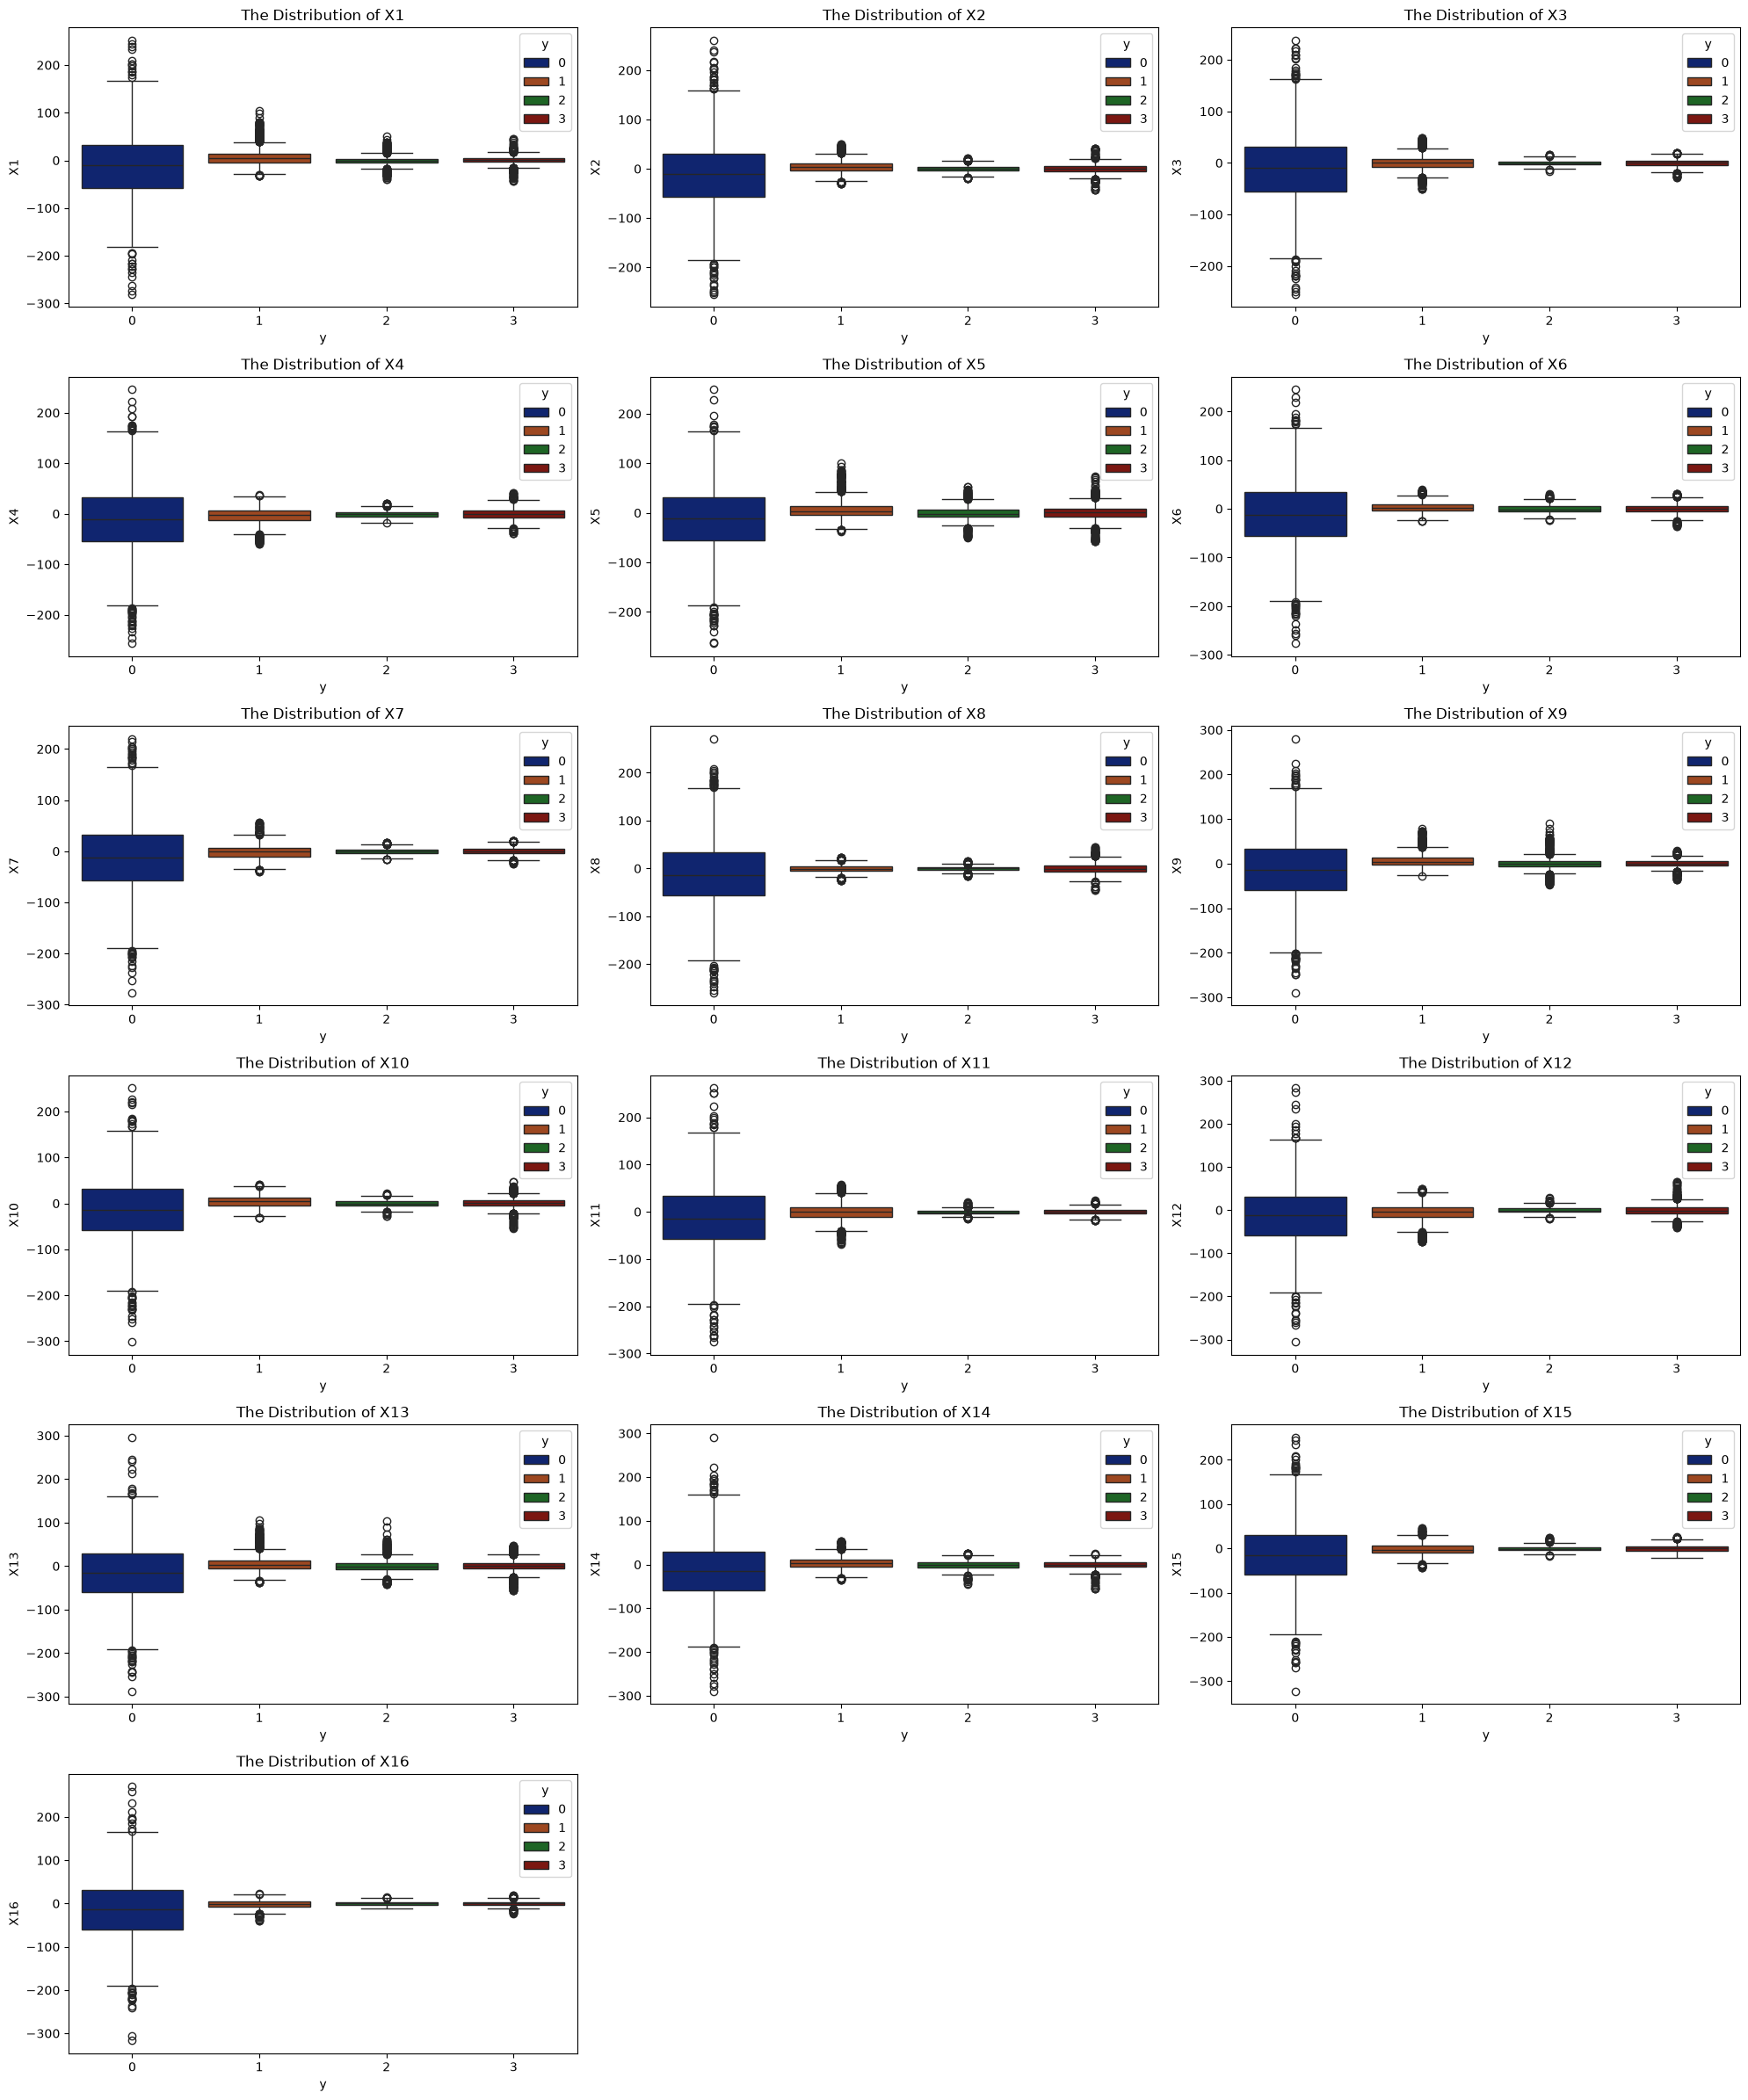

In [12]:
fig , ax = plt.subplots(6,3,figsize=(20,24))
ax = ax.flatten()

for i , col in enumerate(df.columns[:-1]):

        sns.boxplot(
            y=df[col],
            x=df['y'],
            hue=df['y'],
            palette="dark",
            ax=ax[i],
            )
        ax[i].set_title(f"The Distribution of {col}") 
    
for j in range(len(df.columns[:-1]), len(ax)):
        fig.delaxes(ax[j])


plt.tight_layout()



**interpretation:**

The boxplots indicate that samples belonging to class 0 (Healthy Subjects) exhibit substantially greater variability across nearly all features than the seizure-related classes (1, 2, and 3). This is reflected by the wider interquartile ranges (IQRs), longer whiskers, and a larger number of extreme observations. In contrast, classes 1, 2, and 3 display more compact distributions, suggesting lower variability within these groups.


**Class Separation:**

The median values of the four classes are often close to one another.
Therefore, individual features may not provide strong class separation on their own.
This suggests that the classifier will likely benefit from learning multivariate relationships among several features rather than relying on any single feature.


<Axes: >

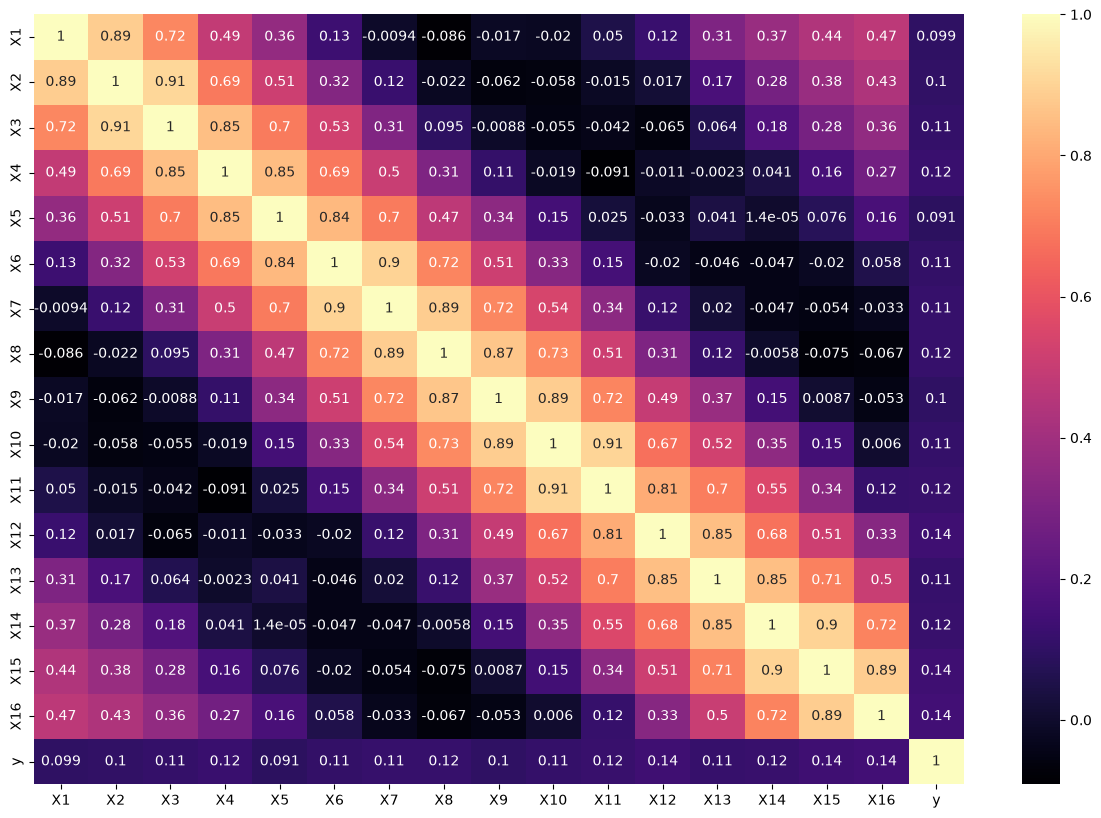

In [13]:
corr = df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr,cmap="magma",annot=True)

**interpretation:**

The correlation analysis reveals a pronounced banded structure among the predictor variables, indicating the presence of strong multicollinearity. Adjacent features exhibit high positive correlations, while the correlation strength generally decreases as the feature indices become more distant. Since the predictor variables correspond to EEG recording channels, this structured correlation is consistent with the fact that neighboring channels often capture related electrical activity. However, because the dataset does not provide the spatial mapping or ordering of the channels, the observed relationship should be interpreted as a statistical pattern rather than direct evidence of anatomical proximity. From a machine learning perspective, these results suggest that several predictors contain overlapping information, which may introduce redundancy for linear models but is generally well handled by tree-based algorithms such as Random Forest and XGBoost. Moreover, the structured rather than random nature of the correlations indicates that the feature set preserves meaningful relationships between the recorded EEG channels, which may be exploited by multivariate learning algorithms.

#### **features informations :** 

in this section we will run a mutual information classifier in order to see how informative each variable as a predictive feature 

In [14]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]
X, y


(       X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
 0       4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
 1      87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
 2    -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
 3      68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
 4     -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   
 ...   ...  ...  ...  ...  ...  ...  ..  ..  ..  ...  ...  ...  ...  ...  ...   
 7995   -9   -4   -7    2   -9  -14  -7  12  -5   -3   -2   -2  -12   -5    4   
 7996   -8   -4   -7    1   -8  -14  -7  12  -6   -3   -2   -3  -15   -4    4   
 7997   -6   -5   -7    1   -8  -14  -7  12  -7   -3   -2   -4  -16   -4    3   
 7998   -5   -6   -6    1   -8  -13  -7  13  -7   -2   -3   -5  -15   -4    3   
 7999   -4   -7   -5    2   -8  -12  -7  14  -6    0   -3   -6  -13   -4    2   
 
       X16  
 0      10  


In [15]:
Mi_score = mutual_info_classif(
    X,
    y,
    random_state=42)

mi = pd.DataFrame(Mi_score, index=df.columns[:-1],columns=['score'])
mi.sort_values(ascending=False,inplace=True,by="score")
mi

,score
X16,0.446994
X11,0.432320
X8,0.430171
X7,0.409006
X15,0.399117
X3,0.383387
X4,0.354881
X10,0.351973
X2,0.351194
X6,0.341552


Text(0.5, 1.0, 'information score across the predictors')

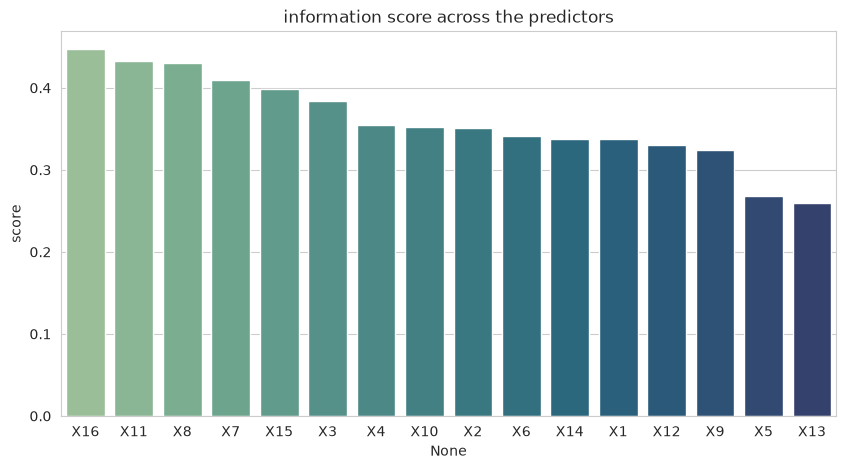

In [16]:
sns.set_style("whitegrid")
plt.figure(figsize=(10,5))
sns.barplot(
    x=mi.index,
    y=mi.score,
    palette='crest'
)

plt.title('information score across the predictors')

**Interpretation**

*the barplot represents the informative score of the predictors (features) .* 

the mutual information analysis indicates than all 16 variable contributes to the classification of the sezuire class , altghough there predictive relevancy varies, suggesting that the discrimonative infortions is distributed across the predictors rather than being concentrented in a subset of features , this lead us to selecting all the features as predictors .

#### Applying PCA to see a scatter point representation of the data 

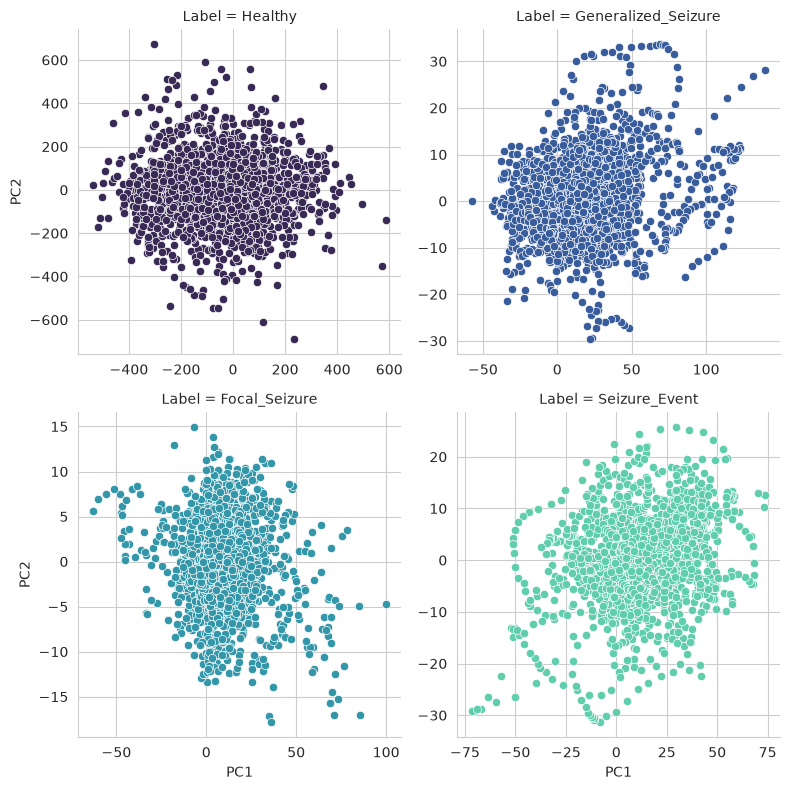

In [28]:

class_labels = {
    "0": "Healthy",
    "1": "Generalized_Seizure",
    "2": "Focal_Seizure",
    "3": "Seizure_Event"
}

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X) 

pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Class': y.astype(str),
    'Label' :pca_df['Class'].map(class_labels)
})



g = sns.FacetGrid(pca_df,
    col="Label",
    col_wrap=2,
    height=4,
    sharex=False,
    sharey=False,
    hue="Label",
    palette="mako"
    )

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2"
)